# Customer Sales Analysis


#### Objective (What to Analyze)

*     Understand customer behavior
*     Identify sales trends
*     Analyze churn patterns
*     Find high-value customers
*     Improve business decision-making


#### Analysis Questions:

*     Who are our most valuable customers?
*     What products sell best together?
*     Which regions have highest sales?
*     What are the seasonal trends?
*     How can we improve customer retention?

#### Import Libraries

In [2]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### Loading & Exploration

#### Load dataset

In [3]:
customer_churn = pd.read_csv(r'C:\Users\shobi\Documents\GitHub\Customer-Sales-Analysis\customer_churn.csv')
sales_data = pd.read_csv(r'C:\Users\shobi\Documents\GitHub\Customer-Sales-Analysis\sales_data.csv')


#### Preview

In [4]:
print(customer_churn.head())
print(sales_data.head())

  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North  

#### Merge data

In [5]:
#merge data
customer_analysis_data = pd.merge(customer_churn, sales_data, left_on='CustomerID',right_on='Customer_ID',how='inner' )
print(customer_analysis_data)

Empty DataFrame
Columns: [CustomerID, Tenure, MonthlyCharges, TotalCharges, Contract, PaymentMethod, PaperlessBilling, SeniorCitizen, Churn, Date, Product, Quantity, Price, Customer_ID, Region, Total_Sales]
Index: []


#### Find missing values

In [6]:
Missing_value = customer_analysis_data.isnull().sum()
print(Missing_value)
print("Missing values = 0")

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
Date                0
Product             0
Quantity            0
Price               0
Customer_ID         0
Region              0
Total_Sales         0
dtype: int64
Missing values = 0


#### Find Duplicate values

In [7]:
Duplicate_values = customer_analysis_data.duplicated().sum()
print("Duplicated values : ",Duplicate_values)

Duplicated values :  0


#### Columns

In [8]:
columns = customer_analysis_data.columns
print(columns)

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn', 'Date',
       'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales'],
      dtype='object')


#### Datatypes

In [9]:
#datdtypes
Data_Types = customer_analysis_data.dtypes
print(Data_Types)

CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
Date                object
Product             object
Quantity             int64
Price                int64
Customer_ID         object
Region              object
Total_Sales          int64
dtype: object


#### Explore data

In [10]:
#describe
Describe = sales_data.describe()
Describe1 = customer_churn.describe()
print(Describe)
print(Describe1)

         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000
           Tenure  MonthlyCharges  TotalCharges  SeniorCitizen       Churn
count  500.000000      500.000000    500.000000     500.000000  500.000000
mean    36.532000      113.636000   4237.882000       0.498000    0.106000
std     20.667057       51.799903   2260.619837       0.500497    0.308146
min      1.000000       20.000000    159.000000       0.000000    0.000000
25%     19.000000       67.000000   2237.250000       0.000000    0.000000
50%     37.000000      115.000000   4182.500000       0.000000    0.000000
75%     54.000000      158.000000   6266.750000     

In [11]:
#info
info = sales_data.info()
info1 = customer_churn.info()
print(info)
print(info1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   P

### Cleaning & Preparation

In [12]:
#Convert Date
sales_data['Date'] = pd.to_datetime(sales_data['Date'])
customer_analysis_data['Date'] = pd.to_datetime(customer_analysis_data['Date'])
print(customer_analysis_data['Date'])

Series([], Name: Date, dtype: datetime64[ns])


In [13]:
#Create a new column for revenue
sales_data['Revenue'] = sales_data['Quantity'] * sales_data['Price']
print(sales_data)

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales  \
0  2024-01-01       Phone         7  37300     CUST001   East       261100   
1  2024-01-02  Headphones         4  15406     CUST002  North        61624   
2  2024-01-03       Phone         2  21746     CUST003   West        43492   
3  2024-01-04  Headphones         1  30895     CUST004   East        30895   
4  2024-01-05      Laptop         8  39835     CUST005  North       318680   
..        ...         ...       ...    ...         ...    ...          ...   
95 2024-04-05      Tablet         8  20770     CUST096  North       166160   
96 2024-04-06  Headphones         1   7647     CUST097   West         7647   
97 2024-04-07      Tablet         5  27196     CUST098   East       135980   
98 2024-04-08     Monitor         1  30717     CUST099  North        30717   
99 2024-04-09  Headphones         5  23376     CUST100  South       116880   

    Revenue  
0    261100  
1     61624  
2     43492  
3     3

### EDA (Sales data)

#### KPI

In [77]:
#Total revenue
Total_Revenue = sales_data['Revenue'].sum()
print("Total Revenue :",Total_Revenue)

#Total Customer
Total_Customer = sales_data['Customer_ID'].nunique()
print("Total Customer :", Total_Customer)

#Average Order Value
Avg_Order_Value = sales_data['Quantity'].mean()
print("Average Order Value :",Avg_Order_Value)

Total Revenue : 12365048
Total Customer : 100
Average Order Value : 4.78


#### Customer valuable

In [90]:
#Top Customer Sales
Top_Customer_Sales = sales_data.groupby('Customer_ID')['Total_Sales'].sum().sort_values(ascending=False).head(1)
def Top_Customer_Sales_Report():
    for Customer_ID, Total_Sales in Top_Customer_Sales.items():
        print(f"Top Customer in Sales : {Customer_ID} : ₹{Total_Sales}")
Top_Customer_Sales_Report()

Top Customer in Sales : CUST016 : ₹373932


In [16]:
#Least Customer Sales
Least_Customer_Sales = sales_data.groupby('Customer_ID')['Total_Sales'].sum().sort_values(ascending=True).head(1)
for Customer_ID, Total_Sales in Least_Customer_Sales.items():
    print("Least Customer in Sales :")
    print(f"{Customer_ID} : ₹{Total_Sales}")

Least Customer in Sales :
CUST054 : ₹6540


#### Region Analysis

In [93]:
#Top Region Sales
Top_Region_Sales = sales_data.groupby('Region')['Total_Sales'].sum().sort_values(ascending= False).head(1)
def Top_Region_Sales_Report():
    for Region,Total_Sales in Top_Region_Sales.items():
        print(f"Top Region in Sales : {Region} : ₹{Total_Sales}")
Top_Region_Sales_Report()

Top Region in Sales : North : ₹3983635


In [18]:
#Least Region Sales
Least_Region_Sales = sales_data.groupby('Region')['Total_Sales'].sum().sort_values(ascending= True).head(1)
for Region,Total_Sales in Least_Region_Sales.items():
    print("Least Region in Sales :")
    print(f"{Region} : ₹{Total_Sales}")

Least Region in Sales :
West : ₹2123922


#### Product analysis

In [94]:
#Top Product Sales
Top_Product_Sales  = sales_data.groupby('Product')['Total_Sales'].sum().sort_values(ascending= False).head(1)
def Top_Product_Sales_Report():
    for Product,Total_Sales in Top_Product_Sales.items():
         print(f"Top Product in Sales :{Product} : ₹{Total_Sales}")
Top_Product_Sales_Report()

Top Product in Sales :Laptop : ₹3889210


In [20]:
#Least Product Sales
Least_Product_Sales  = sales_data.groupby('Product')['Total_Sales'].sum().sort_values(ascending= True).head(1)
for Product,Total_Sales in Least_Product_Sales.items():
     print("Least Product in Sales :")
     print(f"{Product} : ₹{Total_Sales}")

Least Product in Sales :
Monitor : ₹1348071


In [95]:
#Top Product price
Top_Product_Price  = sales_data.groupby('Product')['Price'].sum().sort_values(ascending= False).head(1)
def Top_Product_Price_Report():
    for Product,Price in Top_Product_Price.items():
         print(f"Top Product in Price : {Product} : ₹{Price}")
Top_Product_Price_Report()

Top Product in Price : Laptop : ₹663636


In [22]:
#Least Product price
Least_Product_Price  = sales_data.groupby('Product')['Price'].sum().sort_values(ascending= True).head(1)
for Product,Price in Least_Product_Price.items():
     print("Least Product in Price :")
     print(f"{Product} : ₹{Price}")

Least Product in Price :
Monitor : ₹310645


#### Quantity analysis

In [98]:
#Top quantity sales
Top_Quantity_Sales  = sales_data.groupby('Customer_ID')[['Quantity','Total_Sales']].sum().sort_values(by='Quantity',ascending= False).head(1)
def Top_Quantity_Sales_Report():
    for Customer_ID,row in Top_Quantity_Sales.iterrows():
         print(f"Top Customer in Quantity Purchased : {Customer_ID} : {row['Quantity']} : ₹{row['Total_Sales']}")
Top_Quantity_Sales_Report()


Top Customer in Quantity Purchased : CUST023 : 9 : ₹263475


In [24]:
#Least quantity sales
Least_Quantity_Sales  = sales_data.groupby('Customer_ID')[['Quantity','Total_Sales']].sum().sort_values(by='Quantity',ascending= True).head(1)
for Customer_ID,row in Least_Quantity_Sales.iterrows():
     print("Least Customer in Quantity Purchased :")
     print(f"{Customer_ID} : {row['Quantity']} : ₹{row['Total_Sales']}")

Least Customer in Quantity Purchased :
CUST004 : 1 : ₹30895


#### Month-wise analysis

In [25]:
# Extract Month Number
sales_data['Month'] = sales_data['Date'].dt.month

# Extract Month Name (DIRECTLY from Date)
sales_data['Month_Name'] = sales_data['Date'].dt.month_name()


# Print results
print(sales_data[['Month', 'Month_Name']])

#Group by Month + Customer
month_customer_sales = sales_data.groupby(
    ['Month_Name', 'Customer_ID']
)['Total_Sales'].sum().reset_index()

    Month Month_Name
0       1    January
1       1    January
2       1    January
3       1    January
4       1    January
..    ...        ...
95      4      April
96      4      April
97      4      April
98      4      April
99      4      April

[100 rows x 2 columns]


In [26]:
#Top month wise sales customer
Least_month_sales = month_customer_sales.loc[
    month_customer_sales.groupby('Month_Name')['Total_Sales'].idxmin()
]
for _, row in Least_month_sales.iterrows():
    print("Least Customer in Each Month:")
    print(f"{row['Month_Name']} : {row['Customer_ID']} : ₹{row['Total_Sales']}")

Least Customer in Each Month:
April : CUST097 : ₹7647
Least Customer in Each Month:
February : CUST054 : ₹6540
Least Customer in Each Month:
January : CUST022 : ₹13426
Least Customer in Each Month:
March : CUST091 : ₹7148


In [99]:
#Top month wise sales customer
top_month_sales = month_customer_sales.loc[
    month_customer_sales.groupby('Month_Name')['Total_Sales'].idxmax()
]
def Top_Month_Sales_Report():
    for _, row in top_month_sales.iterrows():
        print(f"Top Customer in Each Month: {row['Month_Name']} : {row['Customer_ID']} : ₹{row['Total_Sales']}")
Top_Month_Sales_Report()

Top Customer in Each Month: April : CUST093 : ₹256878
Top Customer in Each Month: February : CUST043 : ₹260100
Top Customer in Each Month: January : CUST016 : ₹373932
Top Customer in Each Month: March : CUST083 : ₹350888


In [88]:
#Top Month Sales
Top_month_sales  = sales_data.groupby('Month_Name')['Total_Sales'].sum().sort_values(ascending= False).head(1)
def Top_Month_Sales_Report():
    for Month_Name,Total_Sales in Top_month_sales.items():
         print(f"Top Month in Sales : {Month_Name} : ₹{Total_Sales}")
Top_Month_Sales_Report()

Top Month in Sales :March : ₹4485006


In [29]:
#Least Month Sales
Least_month_sales  = sales_data.groupby('Month_Name')['Total_Sales'].sum().sort_values(ascending= True).head(1)
for Month_Name,Total_Sales in Least_month_sales.items():
     print("Least Month in Sales :")
     print(f"{Month_Name} : ₹{Total_Sales}")

Least Month in Sales :
April : ₹1103468


### EDA (Customer churn)

#### Customer Value Insights

In [100]:
# Total customers
total_customers = customer_churn['CustomerID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 500


In [31]:
#Sum of total charges
Total_Revenue_Customerchurn = customer_churn['TotalCharges'].sum()
#Average of total charges
Avg_of_totalcharges = customer_churn['TotalCharges'].mean()
print(f"Total Revenue : ₹{Total_Revenue_Customerchurn}")
print(f"Average of total charges : ₹{Avg_of_totalcharges}")


Total Revenue : ₹2118941
Average of total charges : ₹4237.882


In [102]:
#Top Customer total charges
Top_customer_totalcharges  = customer_churn.groupby('CustomerID')['TotalCharges'].sum().sort_values(ascending= False).head(1)
def Top_customer_totalcharges_report():
    for CustomerID,TotalCharges in Top_customer_totalcharges.items():
         print(f"Top Customer in Total charges : {CustomerID} : ₹{TotalCharges}")
Top_customer_totalcharges_report()

Top Customer in Total charges : C00192 : ₹7992


In [33]:
#Least Customer total charges
Least_customer_totalcharges  = customer_churn.groupby('CustomerID')['TotalCharges'].sum().sort_values(ascending= True).head(1)
for CustomerID,TotalCharges in Least_customer_totalcharges.items():
     print("Least Customer in Total charges :")
     print(f"{CustomerID} : ₹{TotalCharges}")

Least Customer in Total charges :
C00202 : ₹159


In [103]:
#Long Tenure Customer
Long_Tenure_Customer = customer_churn.sort_values(
    by=['Tenure', 'TotalCharges'],
    ascending=False
).head(1)
def Long_Tenure_Customer_Report():
    for _, row in Long_Tenure_Customer.iterrows():
        print(f"Longest Tenure Customer: {row['CustomerID']} : Tenure = {row['Tenure']} : ₹{row['TotalCharges']}")
Long_Tenure_Customer_Report()

Longest Tenure Customer: C00194 : Tenure = 71 : ₹6231


In [35]:
#Short Tenure Customer
Short_Tenure_Customer = customer_churn.sort_values(
    by=['Tenure', 'TotalCharges'],
    ascending=True
).head(1)

for _, row in Short_Tenure_Customer.iterrows():
    print("Short Tenure Customer:")
    print(f"{row['CustomerID']} : Tenure = {row['Tenure']} : ₹{row['TotalCharges']}")

Short Tenure Customer:
C00458 : Tenure = 1 : ₹622


#### Tenure Analysis

In [36]:
#average tenure
avg_tenure = customer_churn['Tenure'].mean()
print("Average Tenure:", avg_tenure)

Average Tenure: 36.532


In [37]:
#Long tenure
long_tenure = customer_churn.sort_values(
    by='Tenure', ascending=False
).head(10)

print("Top Long Tenure Customers:")
print(long_tenure[['CustomerID','Tenure']])

Top Long Tenure Customers:
    CustomerID  Tenure
263     C00264      71
50      C00051      71
193     C00194      71
430     C00431      70
74      C00075      70
207     C00208      70
115     C00116      70
293     C00294      70
386     C00387      70
480     C00481      69


#### Contract Type Insights

In [38]:
#Contract wise analysis
contract_analysis = customer_churn.groupby('Contract')['CustomerID'].count()
print("Customers by Contract Type:")
print(contract_analysis)

Customers by Contract Type:
Contract
Month-to-month    170
One year          186
Two year          144
Name: CustomerID, dtype: int64


#### Payment Method Insights

In [39]:
#payment analysis
payment_analysis = customer_churn.groupby('PaymentMethod')['CustomerID'].count()
print("Payment Method Distribution:")
print(payment_analysis)

Payment Method Distribution:
PaymentMethod
Bank Transfer       159
Credit Card         178
Electronic Check    163
Name: CustomerID, dtype: int64


#### Paperless Billing Insights

In [40]:
#paperless billing insight
paperless_analysis = customer_churn.groupby('PaperlessBilling')['CustomerID'].count()
print("Paperless Billing Usage:")
print(paperless_analysis)

Paperless Billing Usage:
PaperlessBilling
No     257
Yes    243
Name: CustomerID, dtype: int64


#### Senior Citizen Insights

In [41]:
#senior citizens
senior_analysis = customer_churn.groupby('SeniorCitizen')['CustomerID'].count()
print("Senior Citizen Distribution:")
print(senior_analysis)

Senior Citizen Distribution:
SeniorCitizen
0    251
1    249
Name: CustomerID, dtype: int64


#### Monthly Charges Analysis

In [42]:
#month charg analysis
avg_monthly = customer_churn['MonthlyCharges'].mean()
print("Average Monthly Charges:", avg_monthly)

high_monthly = customer_churn.sort_values(
    by='MonthlyCharges', ascending=False
).head(10)

print("Top Monthly Charges Customers:")
print(high_monthly[['CustomerID','MonthlyCharges']])

Average Monthly Charges: 113.636
Top Monthly Charges Customers:
    CustomerID  MonthlyCharges
481     C00482             199
208     C00209             199
401     C00402             199
186     C00187             199
400     C00401             198
219     C00220             198
497     C00498             198
274     C00275             196
375     C00376             196
31      C00032             196


#### Correlation Insight

In [43]:
correlation = customer_churn[['Tenure','MonthlyCharges','TotalCharges']].corr()
print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                  Tenure  MonthlyCharges  TotalCharges
Tenure          1.000000       -0.059655     -0.005677
MonthlyCharges -0.059655        1.000000     -0.042280
TotalCharges   -0.005677       -0.042280      1.000000


#### Customer Segmentation

In [44]:
#customer segmentation
def segment_customer(row):
    if row['TotalCharges'] > 5000:
        return 'High Value'
    elif row['TotalCharges'] > 2000:
        return 'Medium Value'
    else:
        return 'Low Value'

customer_churn['Customer_Segment'] = customer_churn.apply(segment_customer, axis=1)

segment_analysis = customer_churn.groupby('Customer_Segment')['CustomerID'].count()
print("Customer Segmentation:")
print(segment_analysis)

Customer Segmentation:
Customer_Segment
High Value      200
Low Value       108
Medium Value    192
Name: CustomerID, dtype: int64


#### Contract vs Revenue

In [45]:
contract_revenue = customer_churn.groupby('Contract')['TotalCharges'].sum()
print("Revenue by Contract:")
print(contract_revenue)

Revenue by Contract:
Contract
Month-to-month    713273
One year          758052
Two year          647616
Name: TotalCharges, dtype: int64


#### Retention Strategy (Data-Driven Logic Code)

In [46]:
high_risk = customer_churn[
    (customer_churn['Contract'] == 'Month-to-month') &
    (customer_churn['Tenure'] < 12) &
    (customer_churn['MonthlyCharges'] > customer_churn['MonthlyCharges'].mean())
]

print("High Risk Customers Count:", len(high_risk))

High Risk Customers Count: 21


In [47]:
#Create Retention Flag
def retention_strategy(row):
    if row['Contract'] == 'Month-to-month':
        return "Offer Long-Term Plan Discount"
    elif row['Tenure'] < 12:
        return "Engagement & Onboarding Support"
    elif row['MonthlyCharges'] > 70:
        return "Provide Discount / Bundle Offer"
    elif row['PaymentMethod'] == 'Electronic check':
        return "Encourage Auto-Payment"
    else:
        return "Regular Follow-up"

customer_churn['Retention_Action'] = customer_churn.apply(retention_strategy, axis=1)

print(customer_churn[['CustomerID','Retention_Action']].head())


  CustomerID                 Retention_Action
0     C00001  Engagement & Onboarding Support
1     C00002    Offer Long-Term Plan Discount
2     C00003                Regular Follow-up
3     C00004    Offer Long-Term Plan Discount
4     C00005  Provide Discount / Bundle Offer


### Pivot Table

In [48]:
#Sales by Region & Product
pivot_sales = pd.pivot_table(
    sales_data,
    values='Total_Sales',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(pivot_sales)

Product  Headphones   Laptop  Monitor    Phone   Tablet
Region                                                 
East         288361   221946   642870   506828   859634
North        107091  1798206   397100   489284  1191954
South        512168  1373120    39924  1471428   341212
West         476413   495938   268177   391854   491540


In [49]:
#Customer Churn Analysis
pivot_churn = pd.pivot_table(
    customer_churn,
    values='CustomerID',
    index='Contract',
    columns='Churn',
    aggfunc='count',
    fill_value=0
)

print(pivot_churn)

Churn             0   1
Contract               
Month-to-month  135  35
One year        178   8
Two year        134  10


In [50]:
#Revenue by Payment Method
pivot_payment = pd.pivot_table(
    customer_churn,
    values='TotalCharges',
    index='PaymentMethod',
    aggfunc=['sum', 'mean', 'count']
)

print(pivot_payment)

                          sum         mean        count
                 TotalCharges TotalCharges TotalCharges
PaymentMethod                                          
Bank Transfer          664228  4177.534591          159
Credit Card            769015  4320.308989          178
Electronic Check       685698  4206.736196          163


In [51]:
# Monthly Sales Trend
sales_data['Month'] = sales_data['Date'].dt.to_period('M')

pivot_monthly = pd.pivot_table(
    sales_data,
    values='Total_Sales',
    index='Month',
    aggfunc='sum'
)

print(pivot_monthly)

         Total_Sales
Month               
2024-01      4120524
2024-02      2656050
2024-03      4485006
2024-04      1103468


In [52]:
#Senior Citizen vs Charges
pivot_senior = pd.pivot_table(
    customer_churn,
    values='MonthlyCharges',
    index='SeniorCitizen',
    aggfunc=['mean', 'sum']
)

print(pivot_senior)

                        mean            sum
              MonthlyCharges MonthlyCharges
SeniorCitizen                              
0                 119.083665          29890
1                 108.144578          26928


In [53]:
#Quantity Sold by Region & Product
pivot_quantity = pd.pivot_table(
    sales_data,
    values='Quantity',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(pivot_quantity)

Product  Headphones  Laptop  Monitor  Phone  Tablet
Region                                             
East             15       7       29     17      26
North             5      54       20     14      54
South            16      55        1     46      25
West             12      20       16     24      22


### Visualizations

In [54]:
# Ensure numeric
sales_data['Total_Sales'] = pd.to_numeric(sales_data['Total_Sales'], errors='coerce')
sales_data['Revenue'] = pd.to_numeric(sales_data['Revenue'], errors='coerce')
# Convert numeric columns
customer_churn['TotalCharges'] = pd.to_numeric(customer_churn['TotalCharges'], errors='coerce')


#### Sales Trend Over Time (Line Chart)

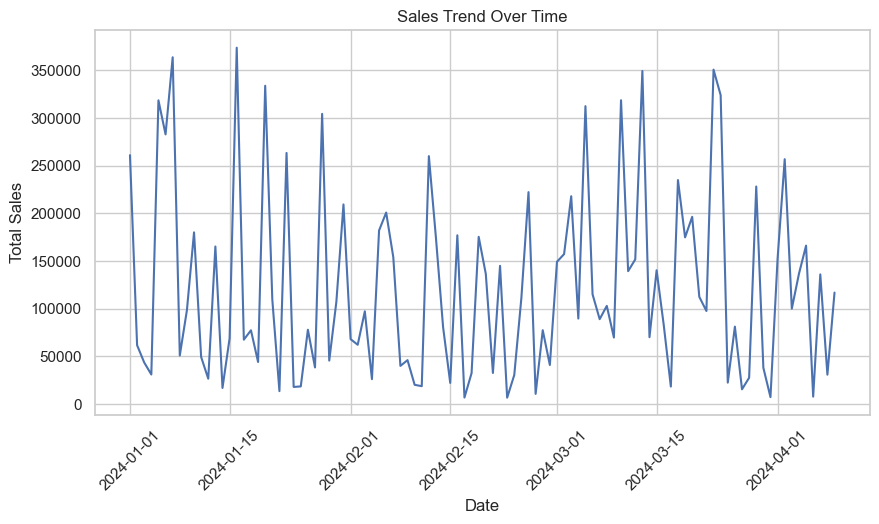

In [113]:
#Sales Trend Over Time (Line Chart)
def Sales_Trend_Chart():
    plt.figure(figsize=(10,5))

    daily_sales = sales_data.groupby('Date')['Total_Sales'].sum()

    sns.lineplot(x=daily_sales.index, y=daily_sales.values)

    plt.title("Sales Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)

    plt.show()
Sales_Trend_Chart()

#### Sales by Region (Bar Chart)

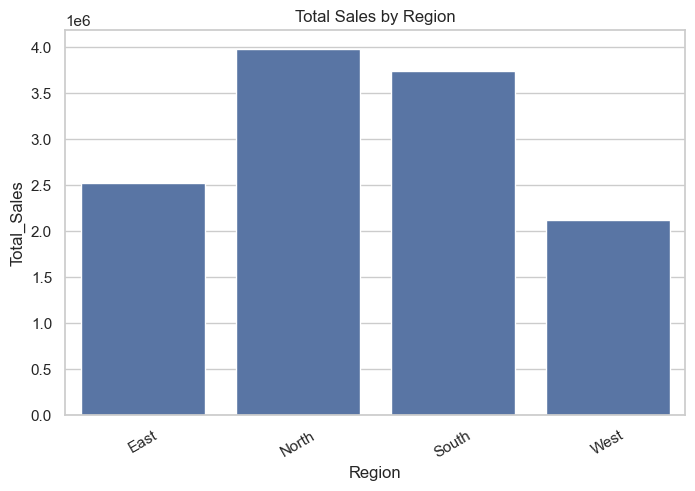

In [115]:
#Sales by Region (Bar Chart)
def Sales_Region_Chart():
    plt.figure(figsize=(8,5))

    region_sales = sales_data.groupby('Region')['Total_Sales'].sum().reset_index()

    sns.barplot(data=region_sales, x='Region', y='Total_Sales')

    plt.title("Total Sales by Region")
    plt.xticks(rotation=30)

    plt.show()
Sales_Region_Chart()

#### Top Products by Revenue

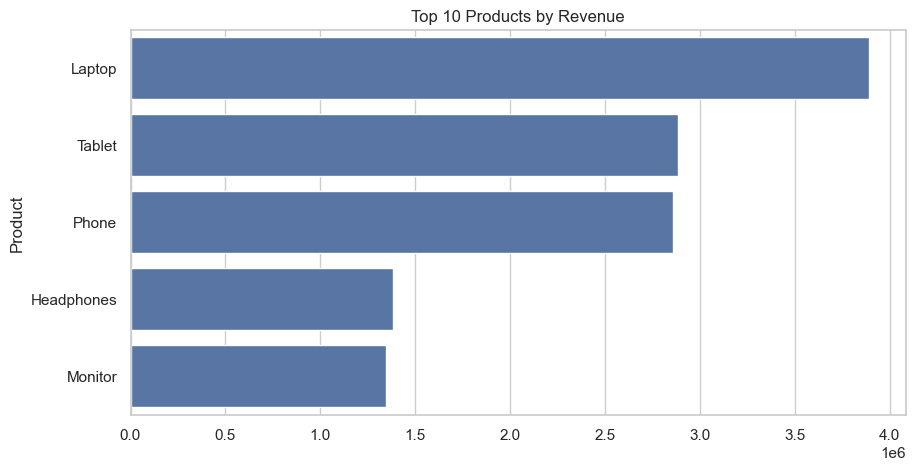

In [119]:
#Top Products by Revenue
def Top_Product_Chart():
    plt.figure(figsize=(10,5))

    product_rev = sales_data.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)

    sns.barplot(x=product_rev.values, y=product_rev.index)

    plt.title("Top 10 Products by Revenue")

    plt.show()
Top_Product_Chart()

#### Monthly Sales Trend

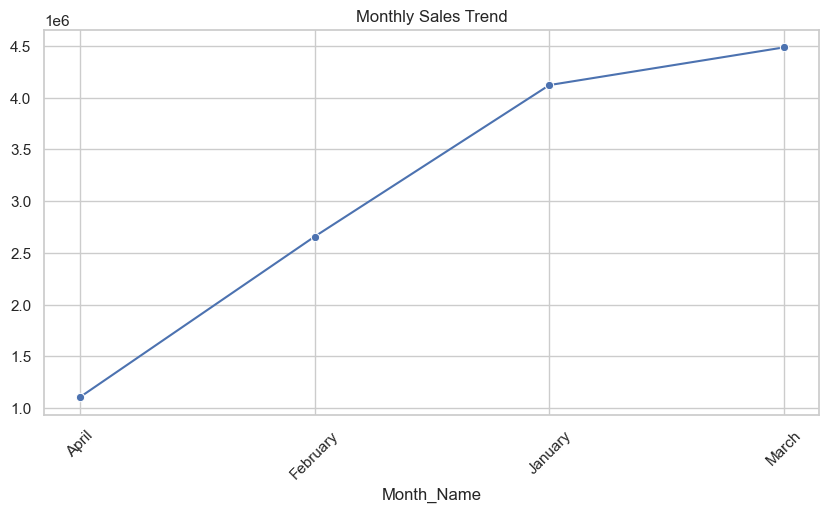

In [116]:
#Monthly Sales Trend
def Month_Sales_Chart():
    plt.figure(figsize=(10,5))

    monthly_sales = sales_data.groupby('Month_Name')['Total_Sales'].sum()

    sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')

    plt.title("Monthly Sales Trend")
    plt.xticks(rotation=45)

    plt.show()
Month_Sales_Chart()

#### Quantity vs Revenue (Scatter Plot)

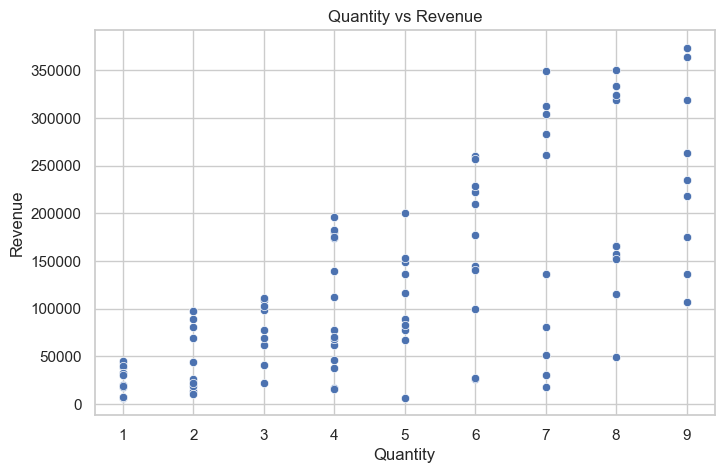

In [122]:
#Quantity vs Revenue (Scatter Plot)
def QVR():
    plt.figure(figsize=(8,5))

    sns.scatterplot(data=sales_data, x='Quantity', y='Revenue')

    plt.title("Quantity vs Revenue")

    plt.show()
QVR()

#### Region-wise Product Heatmap

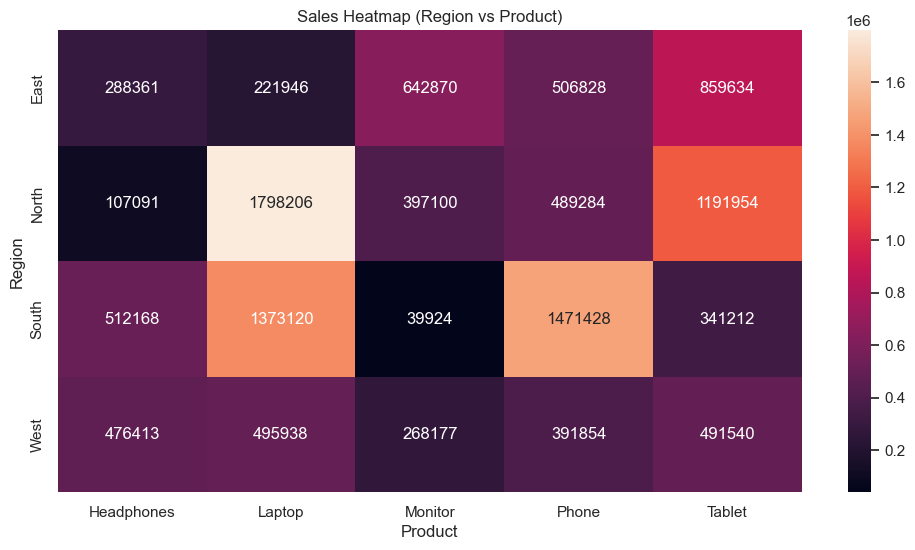

In [117]:
#Region-wise Product Heatmap
def Region_Wise_Chart():
    pivot = sales_data.pivot_table(
        values='Total_Sales',
        index='Region',
        columns='Product',
        aggfunc='sum',
        fill_value=0
    )

    plt.figure(figsize=(12,6))

    sns.heatmap(pivot, annot=True, fmt=".0f")

    plt.title("Sales Heatmap (Region vs Product)")

    plt.show()
Region_Wise_Chart()

#### Churn Count (Target Variable)

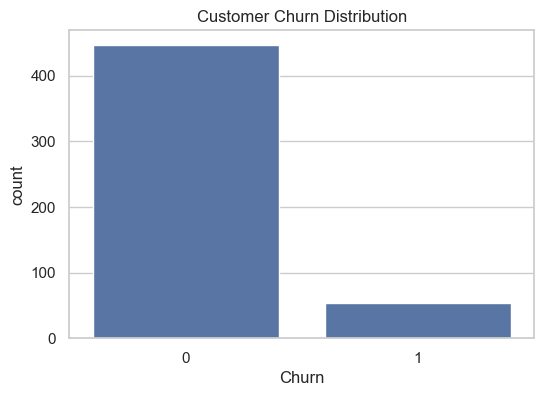

In [61]:
#Churn Count (Target Variable)
plt.figure(figsize=(6,4))

sns.countplot(data=customer_churn, x='Churn')

plt.title("Customer Churn Distribution")

plt.show()

#### Churn by Contract Type

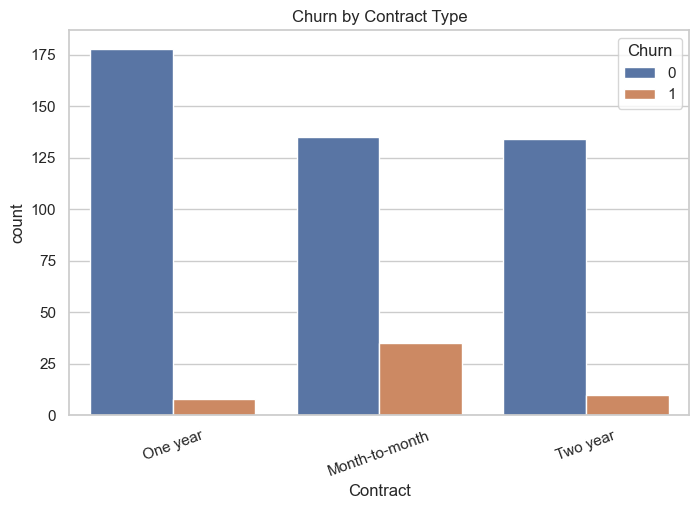

In [62]:
#Churn by Contract Type
plt.figure(figsize=(8,5))

sns.countplot(data=customer_churn, x='Contract', hue='Churn')

plt.title("Churn by Contract Type")
plt.xticks(rotation=20)

plt.show()

#### Monthly Charges vs Churn (Boxplot)

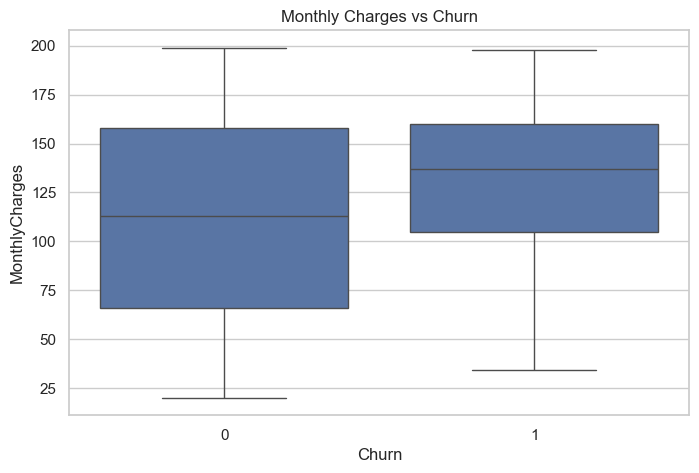

In [63]:
#Monthly Charges vs Churn (Boxplot)
plt.figure(figsize=(8,5))

sns.boxplot(data=customer_churn, x='Churn', y='MonthlyCharges')

plt.title("Monthly Charges vs Churn")

plt.show()

#### Total Charges Distribution

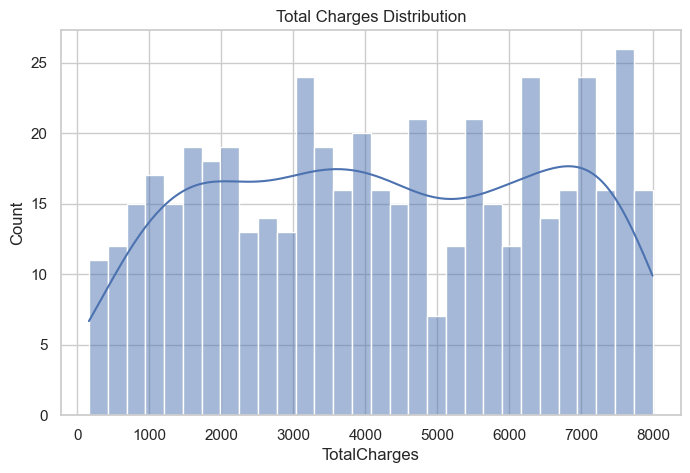

In [64]:
#Total Charges Distribution
plt.figure(figsize=(8,5))

sns.histplot(customer_churn['TotalCharges'], bins=30, kde=True)

plt.title("Total Charges Distribution")

plt.show()

#### Payment Method vs Churn

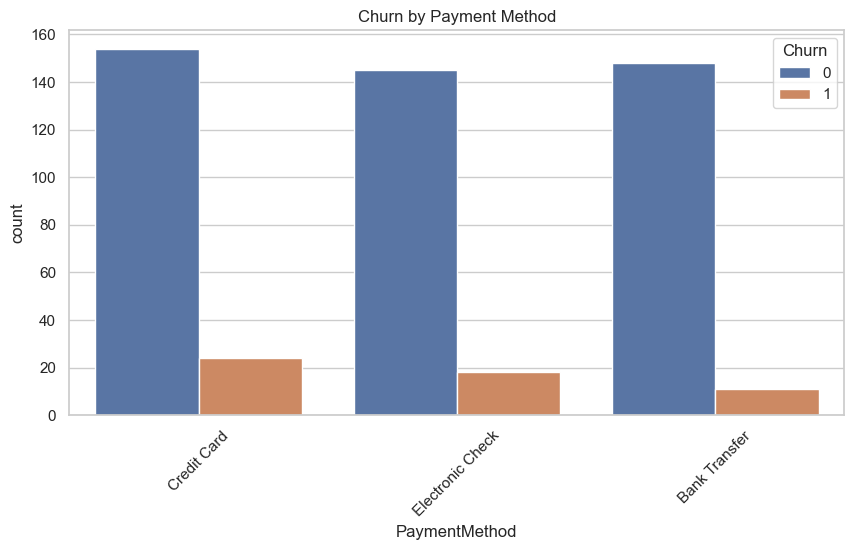

In [65]:
#Payment Method vs Churn
plt.figure(figsize=(10,5))

sns.countplot(data=customer_churn, x='PaymentMethod', hue='Churn')

plt.title("Churn by Payment Method")
plt.xticks(rotation=45)

plt.show()

#### Senior Citizen vs Churn

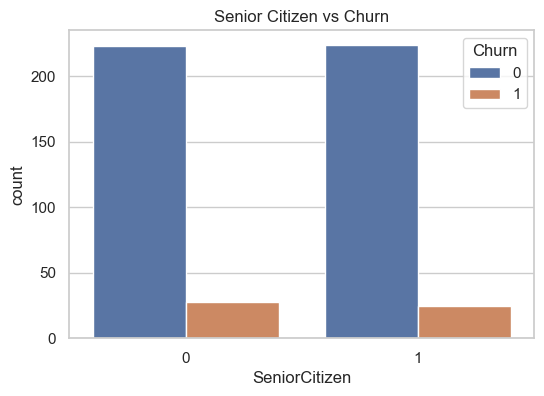

In [66]:
#Senior Citizen vs Churn
plt.figure(figsize=(6,4))

sns.countplot(data=customer_churn, x='SeniorCitizen', hue='Churn')

plt.title("Senior Citizen vs Churn")

plt.show()

#### Paperless Billing Impact

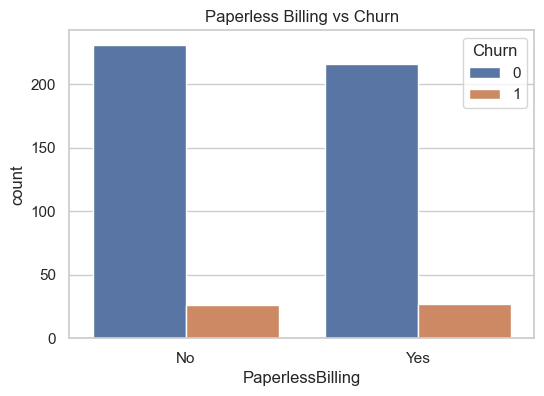

In [67]:
#Paperless Billing Impact
plt.figure(figsize=(6,4))

sns.countplot(data=customer_churn, x='PaperlessBilling', hue='Churn')

plt.title("Paperless Billing vs Churn")

plt.show()

#### Tenure vs Churn (Boxplot)

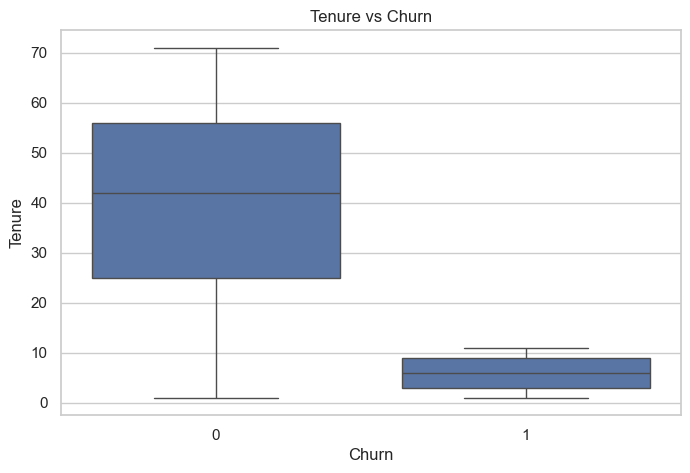

In [68]:
#Tenure vs Churn (Boxplot)
plt.figure(figsize=(8,5))

sns.boxplot(data=customer_churn, x='Churn', y='Tenure')

plt.title("Tenure vs Churn")

plt.show()

#### Customer Segment Analysis

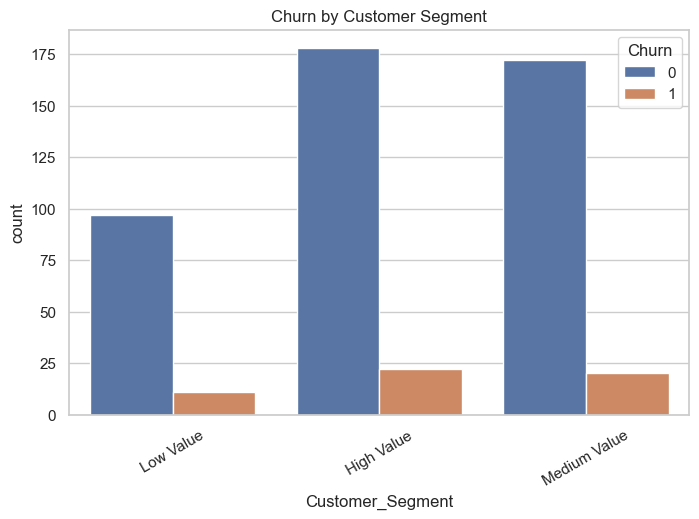

In [69]:
#Customer Segment Analysis
plt.figure(figsize=(8,5))

sns.countplot(data=customer_churn, x='Customer_Segment', hue='Churn')

plt.title("Churn by Customer Segment")
plt.xticks(rotation=30)

plt.show()

#### Correlation Heatmap

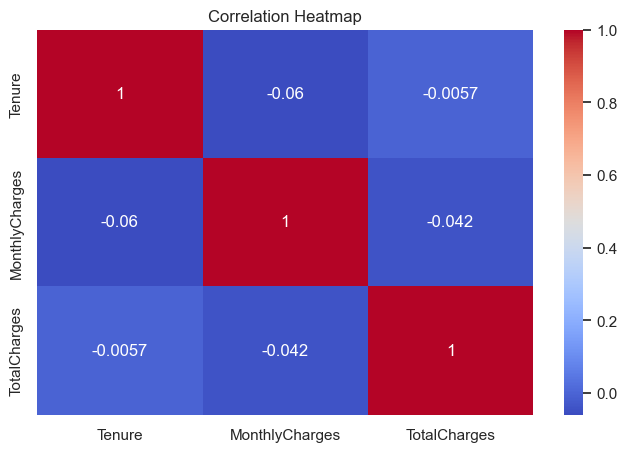

In [70]:
#Correlation Heatmap
plt.figure(figsize=(8,5))

corr = customer_churn[['Tenure','MonthlyCharges','TotalCharges']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Report and Insights

      CUSTOMER SALES ANALYSIS REPORT
Total Revenue      : ₹12,365,048
Total Customers    : 100
Average Order Value: 5
Top Customer in Sales : CUST016 : ₹373932
Top Region in Sales : North : ₹3983635
Top Product in Sales :Laptop : ₹3889210
Top Product in Price : Laptop : ₹663636
Top Customer in Quantity Purchased : CUST023 : 9 : ₹263475
Top Customer in Each Month: April : CUST093 : ₹256878
Top Customer in Each Month: February : CUST043 : ₹260100
Top Customer in Each Month: January : CUST016 : ₹373932
Top Customer in Each Month: March : CUST083 : ₹350888


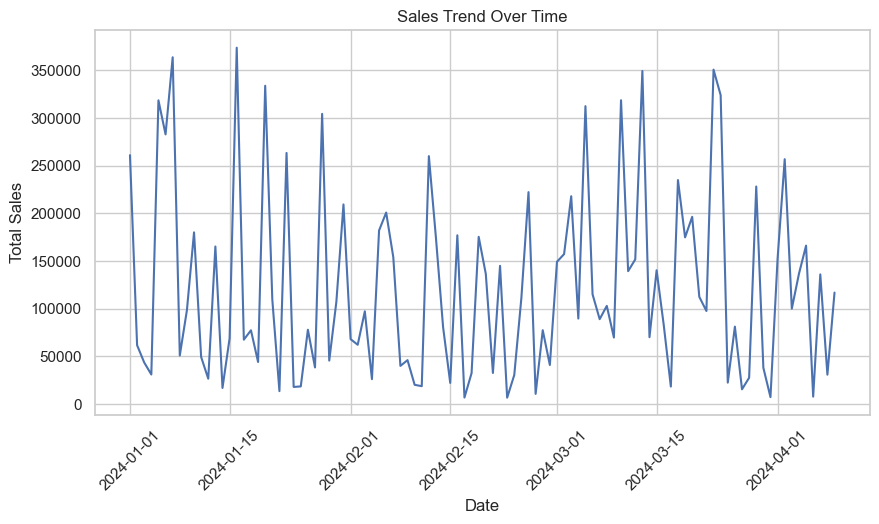

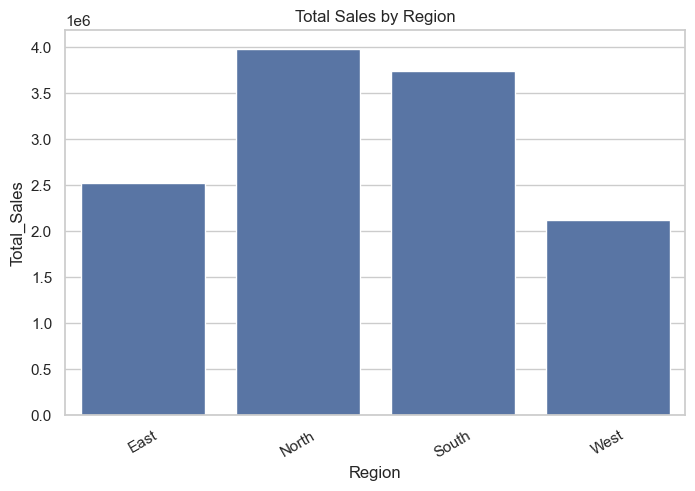

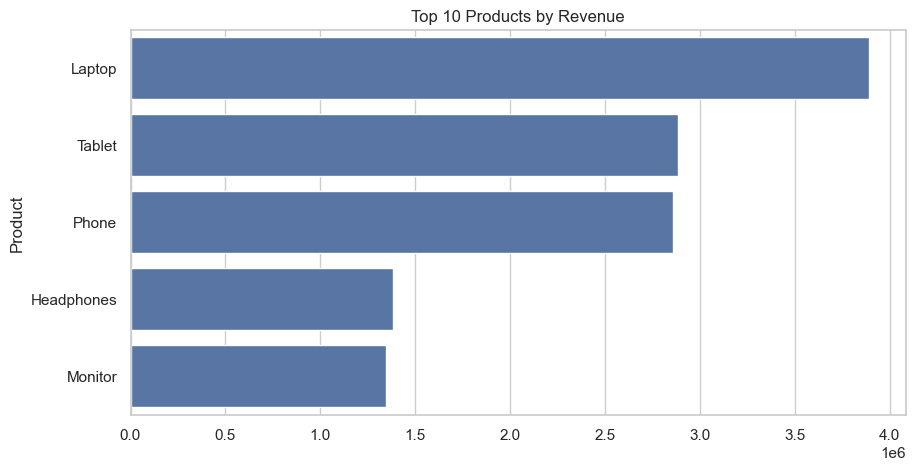

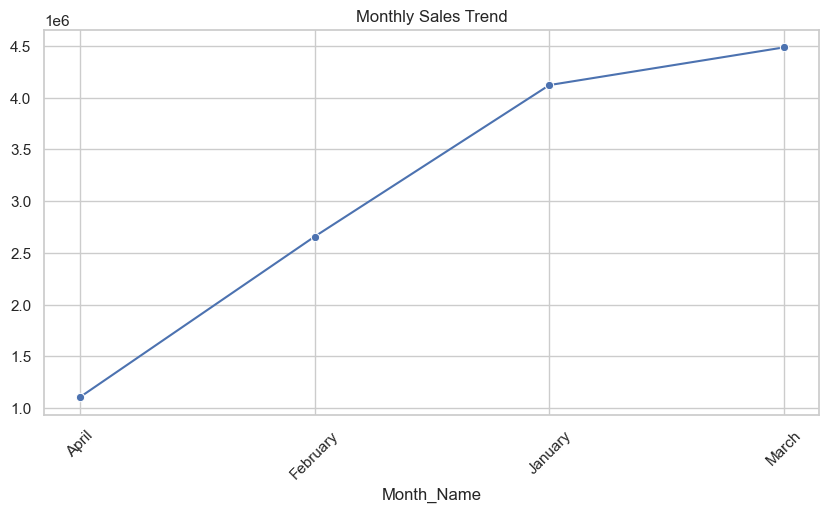

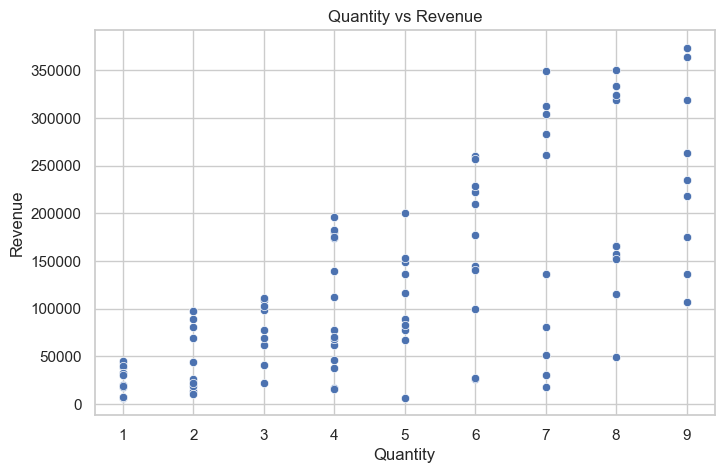

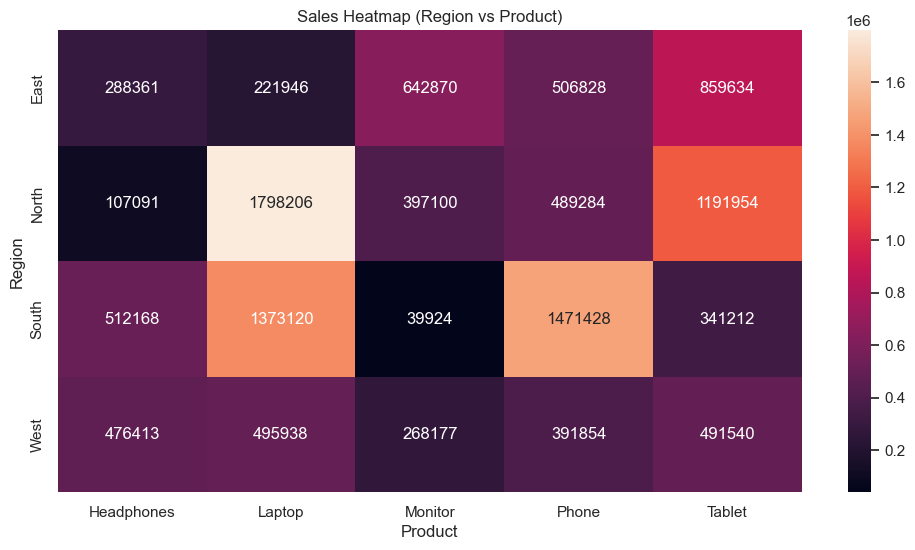

In [123]:
# ── Print Report SALES REPORT ─────────────────────────────────────────────────
print("=" * 45)
print("      CUSTOMER SALES ANALYSIS REPORT")
print("=" * 45)
#total revenue
print(f"Total Revenue      : ₹{Total_Revenue:,.0f}")
#total customers
print(f"Total Customers    : {Total_Customer:,}")
#average order value
print(f"Average Order Value: {Avg_Order_Value:,.0f}")
#top customer sales overall data
Top_Customer_Sales_Report()
#top region sales
Top_Region_Sales_Report()
#top product sales
Top_Product_Sales_Report()
#top product price
Top_Product_Price_Report()
#top quantity sales
Top_Quantity_Sales_Report()
#top month sales
Top_Month_Sales_Report()
#sales trend line chart
Sales_Trend_Chart()
#Sales by Region (Bar Chart)
Sales_Region_Chart()
#Top Products by Revenue
Top_Product_Chart()
#Monthly Sales Trend
Month_Sales_Chart()
#Quantity vs Revenue (Scatter Plot)
QVR()
#Region-wise Product Heatmap
Region_Wise_Chart()


print("=" * 45)

In [125]:
# ── Print Report SALES REPORT ─────────────────────────────────────────────────
print("=" * 45)
print("      CUSTOMER CHURN ANALYSIS REPORT")
print("=" * 45)
#tOTAL CUSTOMERS
print("Total Customers:", total_customers)
#total revenue in customer churn
print(f"Total Revenue : ₹{Total_Revenue_Customerchurn}")
#average total charge
print(f"Average of total charges : ₹{Avg_of_totalcharges}")
#total customer tota charge
Top_customer_totalcharges_report()
#long tenure
Long_Tenure_Customer_Report()
print("Average Tenure:", avg_tenure)
print("Top Long Tenure Customers:")
print(long_tenure[['CustomerID','Tenure']])
#Contract wise analysis
print("Customers by Contract Type:")
print(contract_analysis)
#payment analysis
print("Payment Method Distribution:")
print(payment_analysis)

print("=" * 45)

      CUSTOMER CHURN ANALYSIS REPORT
Total Customers: 500
Total Revenue : ₹2118941
Average of total charges : ₹4237.882
Top Customer in Total charges : C00192 : ₹7992
Longest Tenure Customer: C00194 : Tenure = 71 : ₹6231
Average Tenure: 36.532
Top Long Tenure Customers:
    CustomerID  Tenure
263     C00264      71
50      C00051      71
193     C00194      71
430     C00431      70
74      C00075      70
207     C00208      70
115     C00116      70
293     C00294      70
386     C00387      70
480     C00481      69
Customers by Contract Type:
Contract
Month-to-month    170
One year          186
Two year          144
Name: CustomerID, dtype: int64
Payment Method Distribution:
PaymentMethod
Bank Transfer       159
Credit Card         178
Electronic Check    163
Name: CustomerID, dtype: int64
